In [18]:
# Install required libraries (if not already installed)
!pip install statsmodels matplotlib pandas numpy scikit-learn xgboost prophet

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from xgboost import XGBRegressor
from prophet import Prophet

# Data Preparation Function

In [19]:

def prepare_data(url):
    """
    Loads and prepares data for time series analysis.
    """
    # Load the dataset
    data = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
    data = data.dropna()

    # Plot the original data
    plt.figure(figsize=(12, 6))
    plt.plot(data['Passengers'], label='Original Data')
    plt.title('Original Data')
    plt.xlabel('Year')
    plt.ylabel('Passengers')
    plt.legend()
    plt.show()

    # Differencing for stationarity
    data['Passengers_Diff'] = data['Passengers'].diff()
    data['Passengers_Diff2'] = data['Passengers'].diff().diff()

    # ACF and PACF plots
    plt.figure(figsize=(12, 6))
    plt.subplot(121)
    plot_acf(data['Passengers_Diff2'].dropna(), lags=30, ax=plt.gca(), title="ACF (2nd Differenced Data)")
    plt.subplot(122)
    plot_pacf(data['Passengers_Diff2'].dropna(), lags=30, ax=plt.gca(), title="PACF (2nd Differenced Data)")
    plt.tight_layout()
    plt.show()

    # Split the data into training and testing sets
    train_size = int(len(data) * 0.8)
    train, test = data[:train_size], data[train_size:]

    return train, test, data


# Common Function for Model Evaluation and Plotting

In [20]:
from scipy.stats import probplot
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

from scipy.stats import probplot, shapiro
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_and_plot(model_name, actual, predicted, need_visualize=False):
    """
    Evaluates the model and plots:
    - Actual vs Predicted values
    - Q-Q plot of residuals
    - Histogram of residuals
    Includes residual analysis with comments based on results.
    """
    # Calculate residuals
    residuals = actual - predicted

    # Calculate metrics
    rmse = mean_squared_error(actual, predicted, squared=False)
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    if need_visualize:
        # Print metrics
        print(f"\n{model_name} Performance Metrics:")
        print(f"RMSE: {rmse:.2f}")
        print(f"MAE: {mae:.2f}")
        print(f"MSE: {mse:.2f}")
        print(f"MAPE: {mape:.2f}%")

        # Plot actual vs predicted
        plt.figure(figsize=(12, 6))
        plt.plot(actual.index, actual, label="Actual Data (Test)", color="blue")
        plt.plot(actual.index, predicted, label=f"{model_name} Predictions", color="red", linestyle="--")
        plt.title(f"{model_name}: Actual vs Predicted")
        plt.xlabel("Time")
        plt.ylabel("Values")
        plt.legend()
        plt.show()

        # Q-Q Plot for residuals
        plt.figure(figsize=(8, 6))
        probplot(residuals, dist="norm", plot=plt)
        plt.title(f"{model_name}: Q-Q Plot of Residuals")
        plt.show()

        # Histogram of residuals
        plt.figure(figsize=(8, 6))
        plt.hist(residuals, bins=20, edgecolor='k', color='skyblue')
        plt.title(f"{model_name}: Histogram of Residuals")
        plt.xlabel("Residuals")
        plt.ylabel("Frequency")
        plt.show()

        # Residual Analysis
        print("\nResidual Analysis:")

        # Shapiro-Wilk Test for Normality
        stat, p = shapiro(residuals)
        print(f"  Shapiro-Wilk Test: Statistic={stat:.4f}, p-value={p:.4f}")
        if p > 0.05:
            print("  Residuals are likely normally distributed (fail to reject H0).")
        else:
            print("  Residuals are not normally distributed (reject H0).")

        # Analyze Q-Q Plot
        print("  Q-Q Plot Analysis:")
        print("    - If residuals align closely with the 45-degree line, they are normally distributed.")
        print("    - Deviations at the tails indicate skewness or heavy tails.")

        # Histogram Analysis
        print("  Histogram Analysis:")
        print("    - The histogram should resemble a bell curve if residuals are normal.")
        print("    - Skewness or multimodal shapes suggest issues with model fit.")

        # ACF Analysis Comment (Optional)
        print("  Recommendation: Check autocorrelation of residuals to ensure independence.")

    return {"Model": model_name, "RMSE": rmse, "MAE": mae, "MSE": mse, "MAPE": mape}

# SARIMA Model Function

In [4]:

def sarima_model(train, test, need_visualize=False):
    print("Running SARIMA Model...")
    sarima = SARIMAX(train['Passengers'], order=(1, 2, 1), seasonal_order=(0, 1, 1, 12),
                     enforce_stationarity=False, enforce_invertibility=False)
    result = sarima.fit()
    if need_visualize:
        print(result.summary())
        result.plot_diagnostics(figsize=(15, 12))
        plt.show()
    forecast = result.forecast(steps=len(test))

    return evaluate_and_plot("SARIMA", test['Passengers'], forecast, need_visualize)


# Random Forest Model Function

In [21]:

def random_forest_model(train, test, need_visualize=False):
    print("Running Random Forest Model...")

    # Prepare lagged features
    train['Lag1'] = train['Passengers'].shift(1)
    test['Lag1'] = test['Passengers'].shift(1)

    # Drop NaNs introduced by shifting
    train = train.dropna()
    test = test.dropna()

    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(train[['Lag1']], train['Passengers'])

    # Predict on test data
    forecast = rf.predict(test[['Lag1']])

    return evaluate_and_plot("Random Forest", test['Passengers'], forecast, need_visualize)

# Prophet Model Function

In [22]:

def prophet_model(train, test, need_visualize=False):
    print("Running Prophet Model...")

    # Prepare data for Prophet
    prophet_train = train.reset_index().rename(columns={"Month": "ds", "Passengers": "y"})
    prophet_test = test.reset_index().rename(columns={"Month": "ds"})

    # Train Prophet
    model = Prophet()
    model.fit(prophet_train)

    # Make predictions
    future = prophet_test[['ds']]
    forecast = model.predict(future)
    predictions = forecast['yhat'].values

    # Plot Prophet Components
    print(f"\nProphet Components:")
    if need_visualize:
        model.plot_components(forecast)
        plt.show()

    return evaluate_and_plot("Prophet", test['Passengers'], predictions, need_visualize)


# XGBoost Model Function

In [23]:

def xgboost_model(train, test, need_visualize=False):
    print("Running XGBoost Model...")

    # Prepare lagged features
    train['Lag1'] = train['Passengers'].shift(1)
    test['Lag1'] = test['Passengers'].shift(1)

    # Drop NaNs introduced by shifting
    train = train.dropna()
    test = test.dropna()

    # Train XGBoost
    xgb = XGBRegressor(n_estimators=100, random_state=42)
    xgb.fit(train[['Lag1']], train['Passengers'])

    # Predict on test data
    forecast = xgb.predict(test[['Lag1']])

    return evaluate_and_plot("XGBoost", test['Passengers'], forecast, need_visualize)


# Main Flow

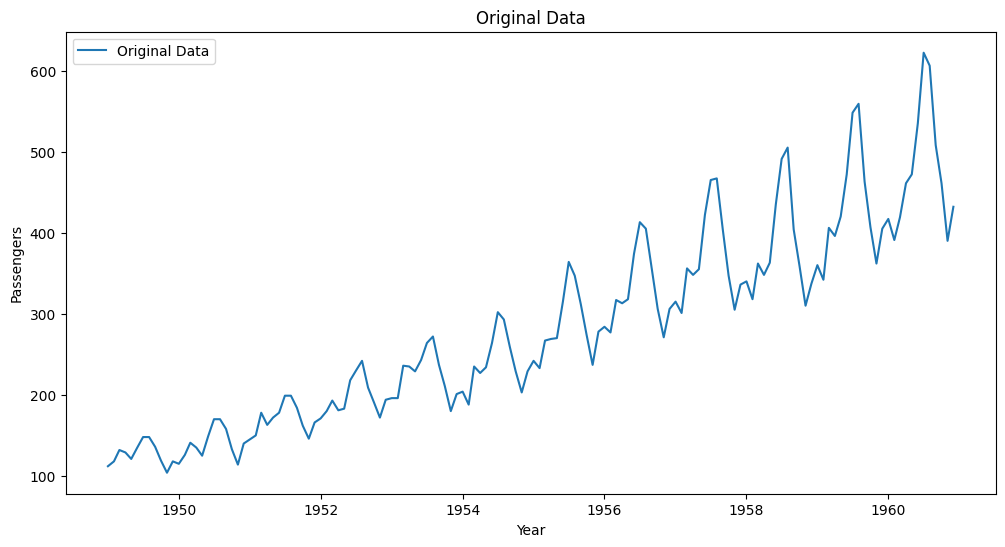

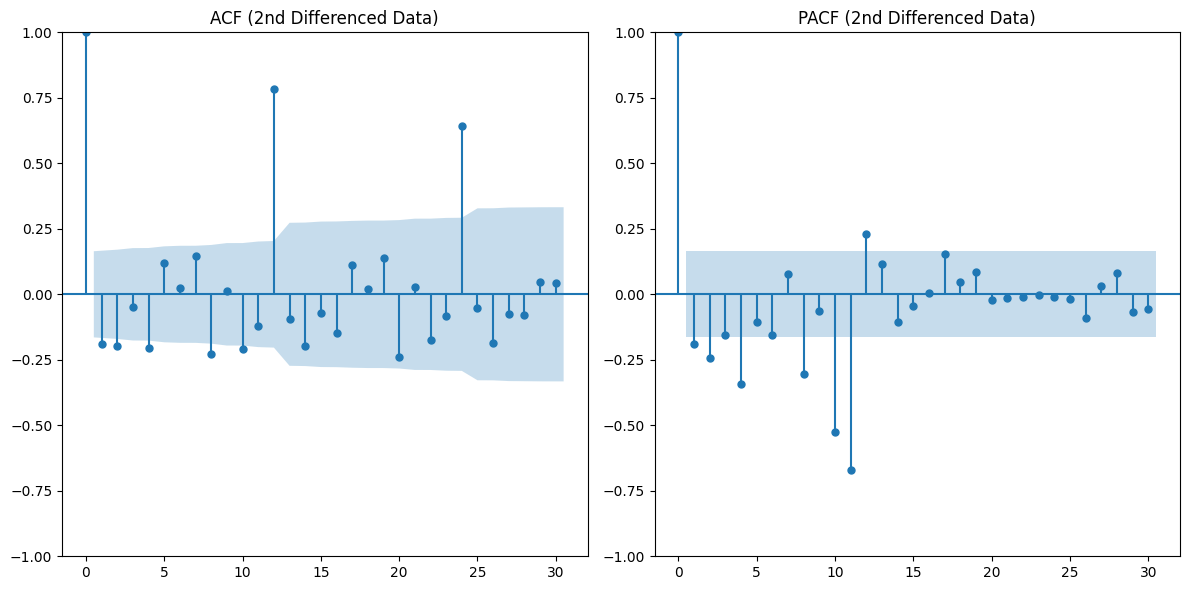

In [24]:

dataset_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
train_data, test_data, full_data = prepare_data(dataset_url)

# Initialize Results Table
results = []

# Run SARIMA

Running SARIMA Model...


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  115
Model:             SARIMAX(1, 2, 1)x(0, 1, 1, 12)   Log Likelihood                -324.268
Date:                            Sun, 24 Nov 2024   AIC                            656.537
Time:                                    17:23:33   BIC                            666.400
Sample:                                01-01-1949   HQIC                           660.509
                                     - 07-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1750      0.104     -1.687      0.092      -0.378       0.028
ma.L1         -1.0000    288.531   

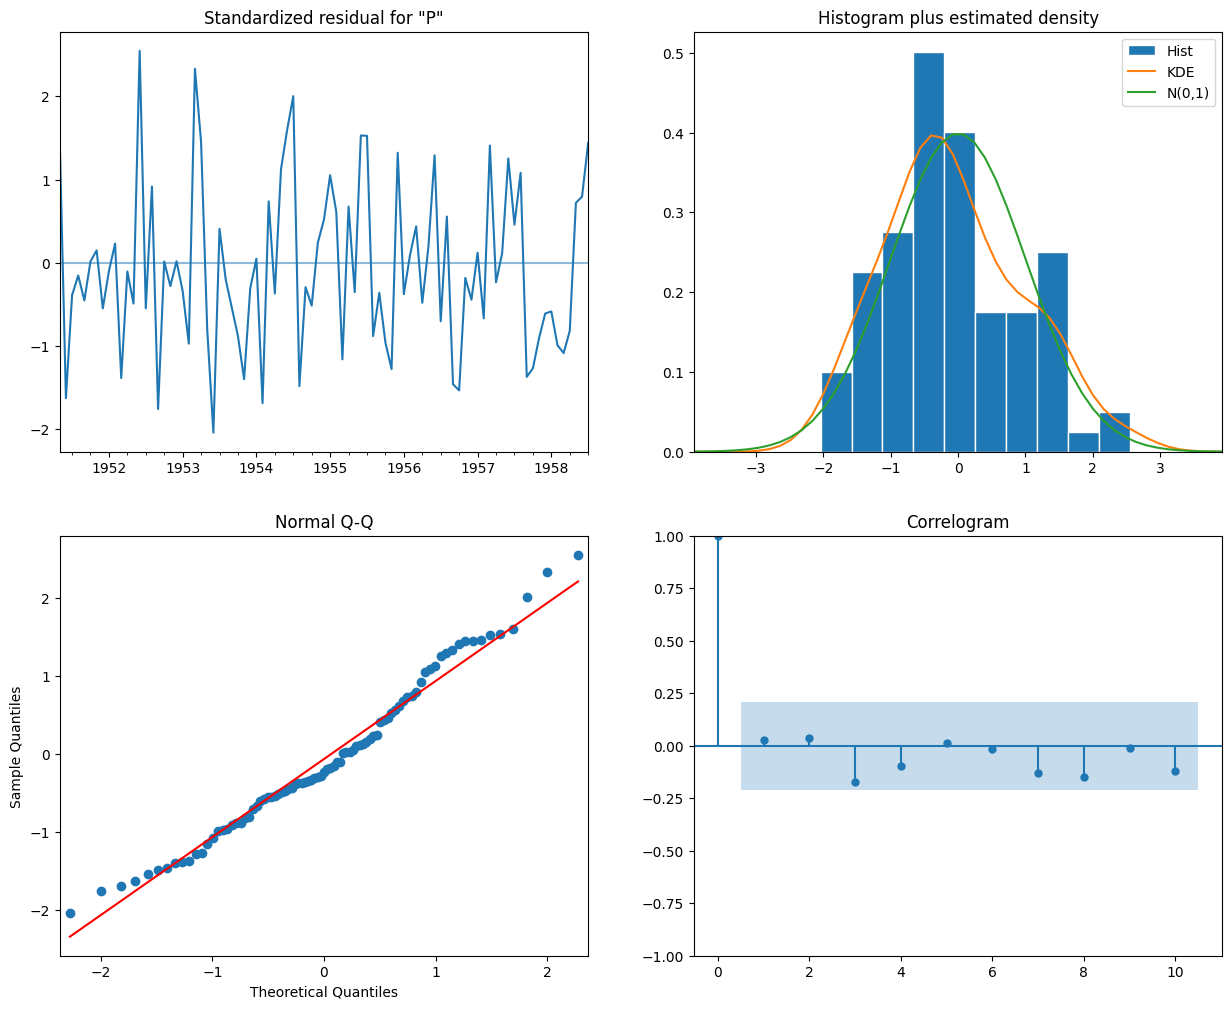

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



SARIMA Performance Metrics:
RMSE: 26.86
MAE: 20.84
MSE: 721.36
MAPE: 4.49%


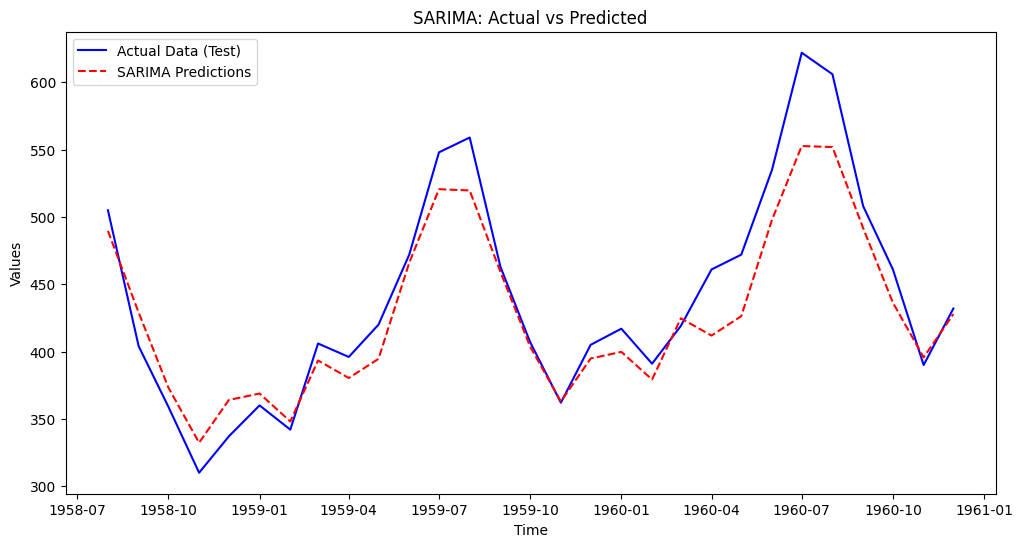

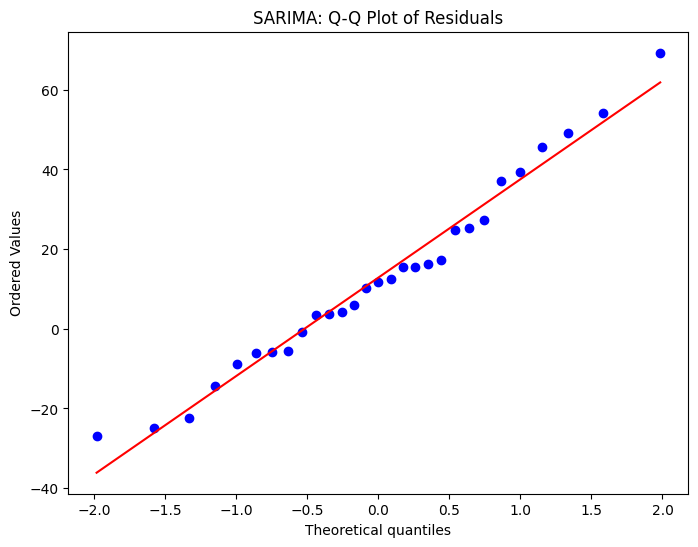

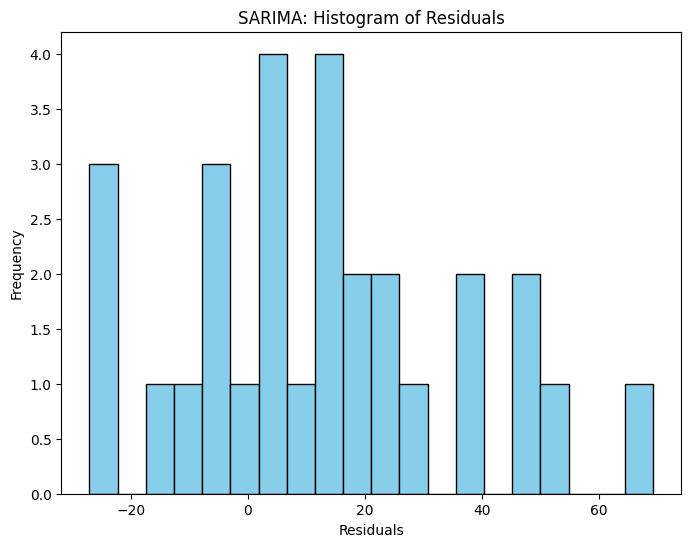


Residual Analysis:
  Shapiro-Wilk Test: Statistic=0.9744, p-value=0.6822
  Residuals are likely normally distributed (fail to reject H0).
  Q-Q Plot Analysis:
    - If residuals align closely with the 45-degree line, they are normally distributed.
    - Deviations at the tails indicate skewness or heavy tails.
  Histogram Analysis:
    - The histogram should resemble a bell curve if residuals are normal.
    - Skewness or multimodal shapes suggest issues with model fit.
  Recommendation: Check autocorrelation of residuals to ensure independence.


In [25]:

results.append(sarima_model(train_data, test_data, need_visualize=True))

# Run Random Forest

Running Random Forest Model...

Random Forest Performance Metrics:
RMSE: 76.71
MAE: 59.61
MSE: 5884.41
MAPE: 12.65%


<ipython-input-21-7edc7b8955bd>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Lag1'] = train['Passengers'].shift(1)
<ipython-input-21-7edc7b8955bd>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Lag1'] = test['Passengers'].shift(1)
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


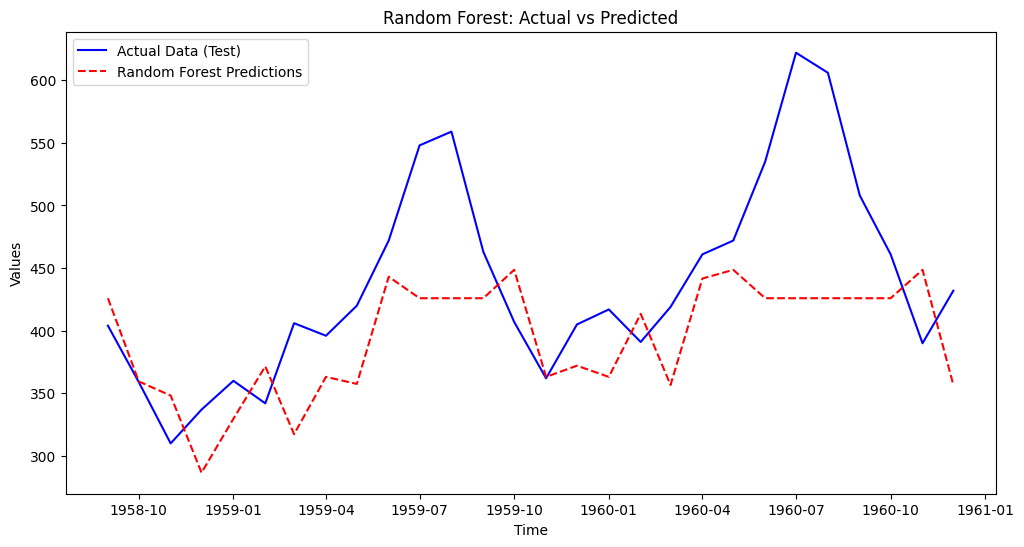

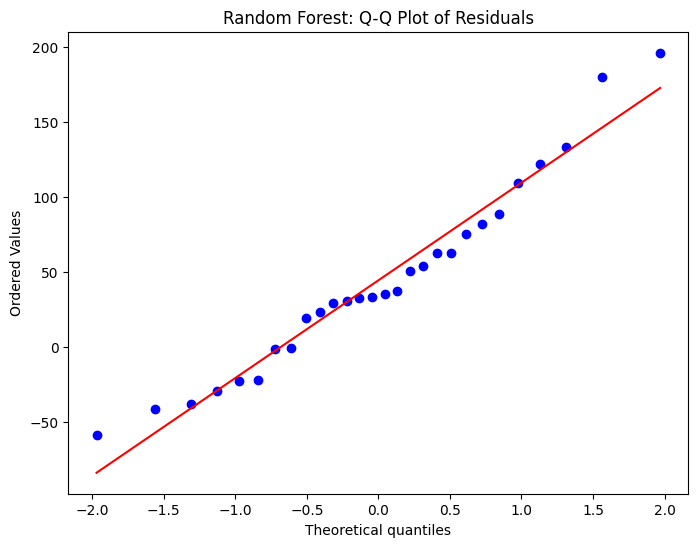

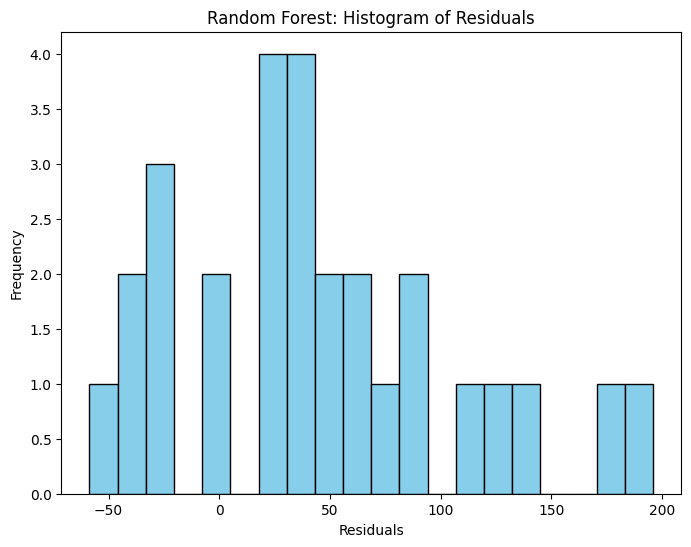


Residual Analysis:
  Shapiro-Wilk Test: Statistic=0.9592, p-value=0.3335
  Residuals are likely normally distributed (fail to reject H0).
  Q-Q Plot Analysis:
    - If residuals align closely with the 45-degree line, they are normally distributed.
    - Deviations at the tails indicate skewness or heavy tails.
  Histogram Analysis:
    - The histogram should resemble a bell curve if residuals are normal.
    - Skewness or multimodal shapes suggest issues with model fit.
  Recommendation: Check autocorrelation of residuals to ensure independence.


In [26]:

results.append(random_forest_model(train_data, test_data, need_visualize=True))

# Run Prophet

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq96yat0m/qsg51p__.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq96yat0m/06mvhccq.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=72334', 'data', 'file=/tmp/tmpq96yat0m/qsg51p__.json', 'init=/tmp/tmpq96yat0m/06mvhccq.json', 'output', 'file=/tmp/tmpq96yat0m/prophet_modelswk7lg2k/prophet_model-20241124172537.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:25:37 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:25:37 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Running Prophet Model...

Prophet Components:


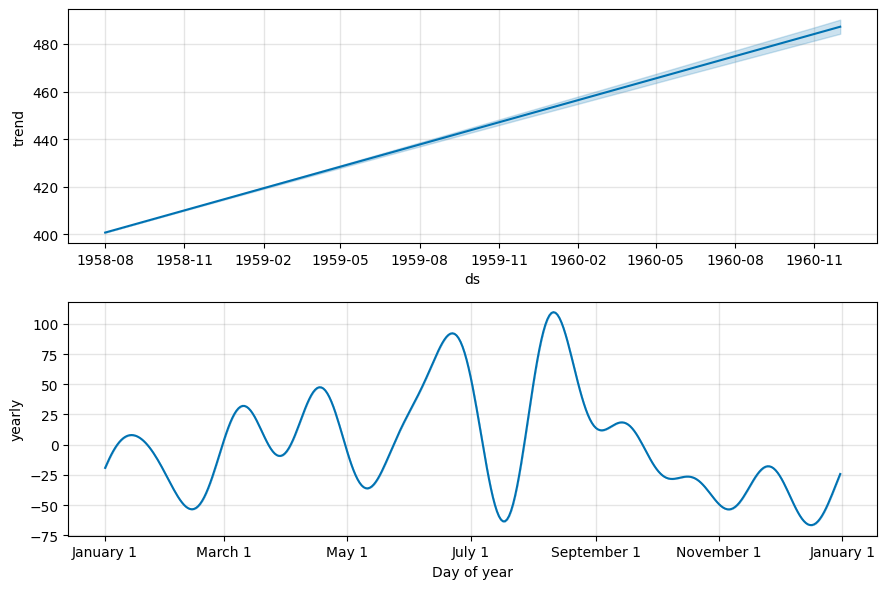

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



Prophet Performance Metrics:
RMSE: 41.33
MAE: 33.89
MSE: 1708.21
MAPE: 7.72%


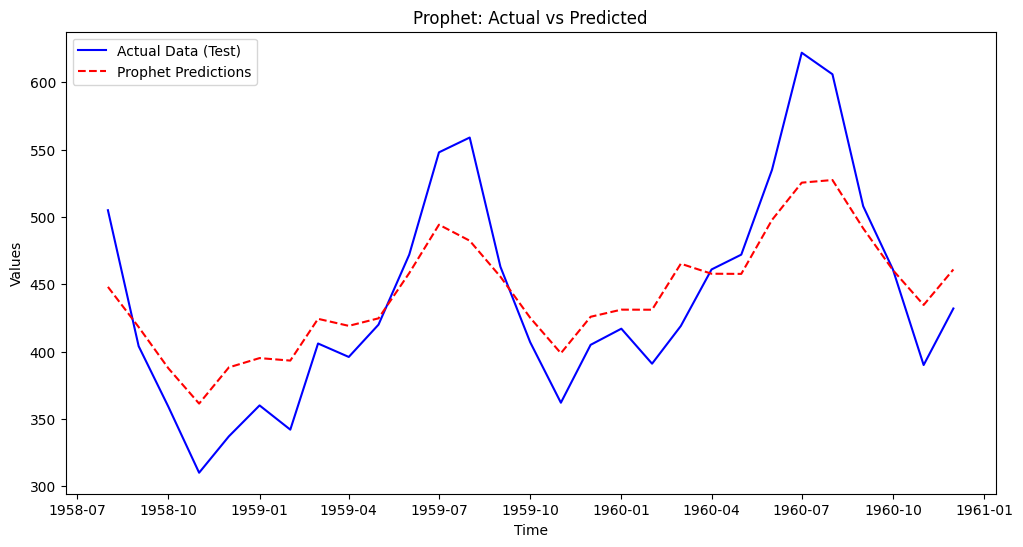

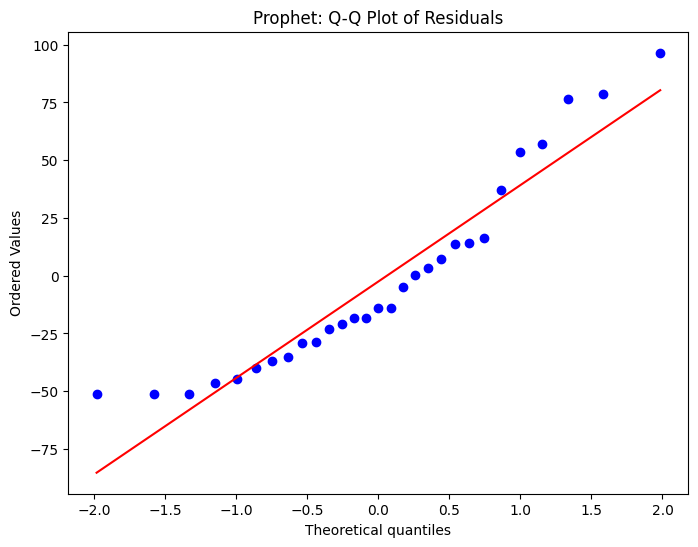

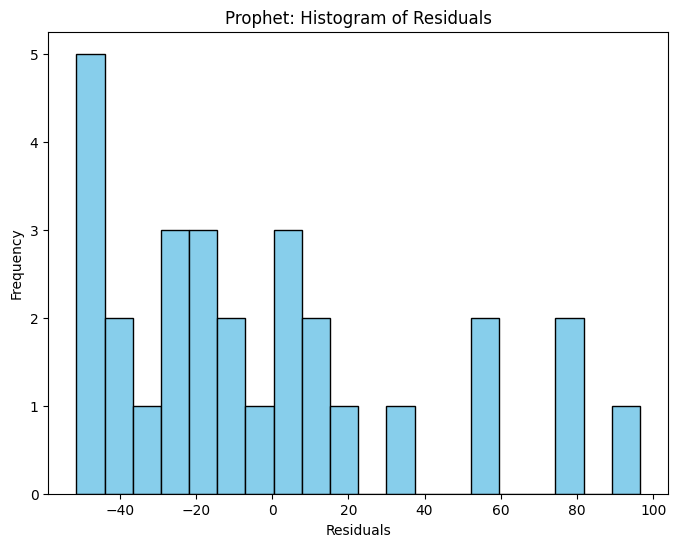


Residual Analysis:
  Shapiro-Wilk Test: Statistic=0.9028, p-value=0.0115
  Residuals are not normally distributed (reject H0).
  Q-Q Plot Analysis:
    - If residuals align closely with the 45-degree line, they are normally distributed.
    - Deviations at the tails indicate skewness or heavy tails.
  Histogram Analysis:
    - The histogram should resemble a bell curve if residuals are normal.
    - Skewness or multimodal shapes suggest issues with model fit.
  Recommendation: Check autocorrelation of residuals to ensure independence.


In [27]:
results.append(prophet_model(train_data, test_data, need_visualize=True))

# Run XGBoost

Running XGBoost Model...

XGBoost Performance Metrics:
RMSE: 87.43
MAE: 64.92
MSE: 7644.87
MAPE: 13.55%


<ipython-input-23-d29960604a82>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Lag1'] = train['Passengers'].shift(1)
<ipython-input-23-d29960604a82>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Lag1'] = test['Passengers'].shift(1)
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


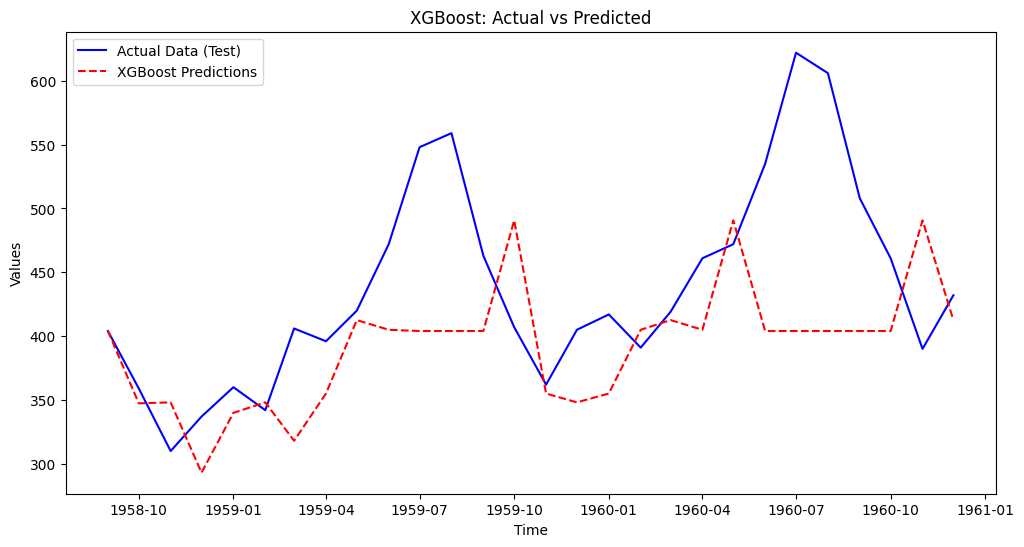

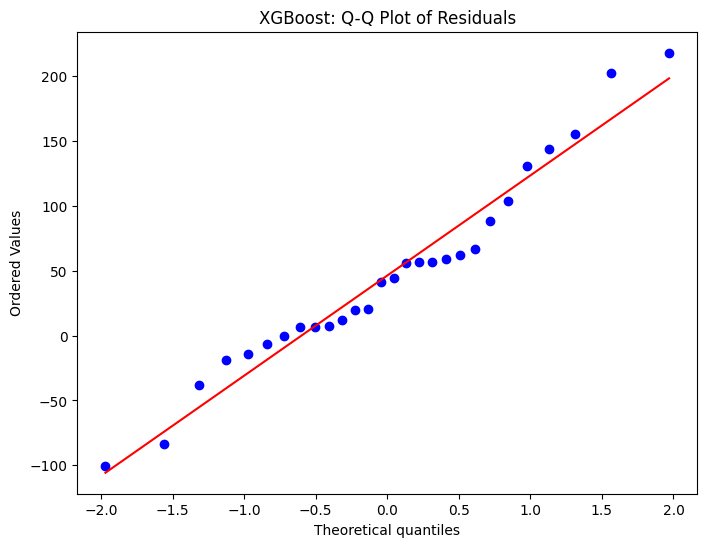

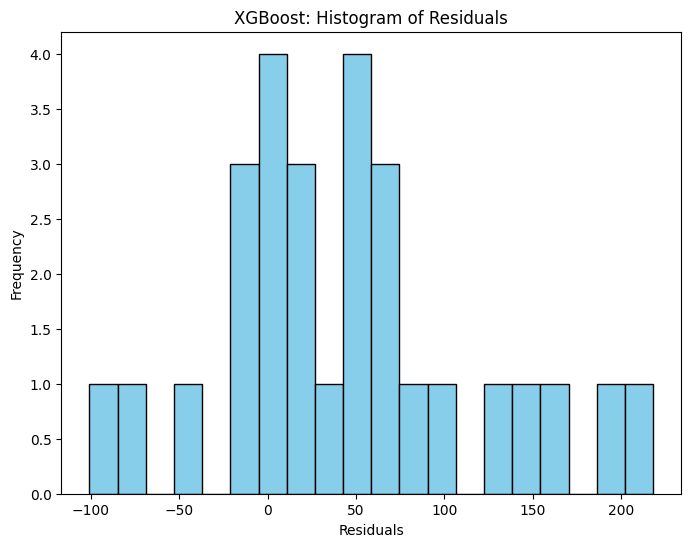


Residual Analysis:
  Shapiro-Wilk Test: Statistic=0.9635, p-value=0.4200
  Residuals are likely normally distributed (fail to reject H0).
  Q-Q Plot Analysis:
    - If residuals align closely with the 45-degree line, they are normally distributed.
    - Deviations at the tails indicate skewness or heavy tails.
  Histogram Analysis:
    - The histogram should resemble a bell curve if residuals are normal.
    - Skewness or multimodal shapes suggest issues with model fit.
  Recommendation: Check autocorrelation of residuals to ensure independence.


In [28]:
results.append(xgboost_model(train_data, test_data, need_visualize=True))

# Create Summary Table

In [29]:
results_df = pd.DataFrame(results)
print("\nSummary of Model Performance:")
print(results_df)


Summary of Model Performance:
           Model       RMSE        MAE          MSE       MAPE
0         SARIMA  26.858097  20.840751   721.357362   4.493211
1  Random Forest  76.709885  59.612685  5884.406493  12.653596
2        Prophet  41.330552  33.893120  1708.214529   7.719153
3        XGBoost  87.434959  64.924411  7644.872110  13.545754


# Cross-Validation

In [30]:
import scipy.stats as stats
from sklearn.model_selection import TimeSeriesSplit

def calculate_confidence_interval(data, confidence=0.95):
    """
    Calculate the confidence interval for a given list of data.

    Parameters:
    - data: list or np.array
        Data for which to calculate the confidence interval.
    - confidence: float
        Confidence level (default is 95%).

    Returns:
    - (mean, lower_bound, upper_bound): tuple
        Mean, lower bound, and upper bound of the confidence interval.
    """
    mean = np.mean(data)
    std_err = stats.sem(data)  # Standard error of the mean
    margin = std_err * stats.t.ppf((1 + confidence) / 2, len(data) - 1)
    return mean, mean - margin, mean + margin

def cross_validate_models_with_ci(models, data, n_splits=5, confidence=0.95):
    """
    Perform time series cross-validation for multiple models with confidence intervals.

    Parameters:
    - models: dict
        Dictionary of model functions. Example: {"SARIMA": sarima_model, "Prophet": prophet_model}
    - data: pd.DataFrame
        Full dataset with time series data.
    - n_splits: int
        Number of splits for cross-validation.
    - confidence: float
        Confidence level for confidence intervals.

    Returns:
    - cv_results: pd.DataFrame
        DataFrame with average performance metrics and confidence intervals for each model.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_results = []

    for model_name, model_func in models.items():
        print(f"\nCross-validating {model_name}...")
        fold_metrics = {"RMSE": [], "MAE": [], "MSE": [], "MAPE": []}

        for fold, (train_idx, test_idx) in enumerate(tscv.split(data)):
            print(f"\nFold {fold + 1}/{n_splits}")
            train, test = data.iloc[train_idx], data.iloc[test_idx]

            # Run the model function and evaluate
            metrics = model_func(train, test)
            for key in fold_metrics:
                fold_metrics[key].append(metrics[key])

        # Calculate mean and confidence intervals for each metric
        model_summary = {"Model": model_name}
        for metric in fold_metrics:
            mean, lower, upper = calculate_confidence_interval(fold_metrics[metric], confidence=confidence)
            model_summary[f"{metric} Mean"] = mean
            model_summary[f"{metric} CI Lower"] = lower
            model_summary[f"{metric} CI Upper"] = upper

        cv_results.append(model_summary)

    # Return results as a DataFrame
    return pd.DataFrame(cv_results)

"""# Run Enhanced Cross-Validation"""

# Define models
model_functions = {
    "SARIMA": sarima_model,
    "Random Forest": random_forest_model,
    "Prophet": prophet_model,
    "XGBoost": xgboost_model
}

# Perform cross-validation with confidence intervals
cv_results_df = cross_validate_models_with_ci(model_functions, full_data, n_splits=5)



Cross-validating SARIMA...

Fold 1/5
Running SARIMA Model...

Fold 2/5
Running SARIMA Model...

Fold 3/5
Running SARIMA Model...


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sta


Fold 4/5
Running SARIMA Model...

Fold 5/5
Running SARIMA Model...


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
<ipython-input-21-7edc7b8955bd>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Lag1'] = train['Passengers'].shift(1)
<ipython-input-21-7edc7b8955bd>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Lag1'] = test['Passengers'].shift(1)
/u


Cross-validating Random Forest...

Fold 1/5
Running Random Forest Model...

Fold 2/5
Running Random Forest Model...


...

17:27:48 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq96yat0m/bfl5_ejs.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq96yat0m/z4l4z6w8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=56945', 'data', 'file=/tmp/tmpq96yat0m/bfl5_ejs.json', 'init=/tmp/tmpq96yat0m/z4l4z6w8.json', 'output', 'file=/tmp/


Prophet Components:

Fold 5/5
Running Prophet Model...

Prophet Components:

Cross-validating XGBoost...

Fold 1/5
Running XGBoost Model...

Fold 2/5
Running XGBoost Model...


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
<ipython-input-23-d29960604a82>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Lag1'] = train['Passengers'].shift(1)
<ipython-input-23-d29960604a82>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Lag1'] = test['Passengers'].shift(1)
/u


Fold 3/5
Running XGBoost Model...

Fold 4/5
Running XGBoost Model...

Fold 5/5
Running XGBoost Model...


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
<ipython-input-23-d29960604a82>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Lag1'] = train['Passengers'].shift(1)
<ipython-input-23-d29960604a82>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Lag1'] = test['Passengers'].shift(1)
/u

In [31]:
# Print cross-validation summary
print("\nCross-Validation Results with Confidence Intervals:")
display(cv_results_df)


Cross-Validation Results with Confidence Intervals:


,Model,RMSE Mean,RMSE CI Lower,RMSE CI Upper,MAE Mean,MAE CI Lower,MAE CI Upper,MSE Mean,MSE CI Lower,MSE CI Upper,MAPE Mean,MAPE CI Lower,MAPE CI Upper
0,SARIMA,81.324271,-40.881722,203.530265,68.119497,-31.291790,167.530783,14363.014683,-20326.697734,49052.727099,29.189096,-26.033765,84.411956
1,Random Forest,53.219218,29.365186,77.073250,41.697329,22.401801,60.992857,3127.545693,420.888972,5834.202413,12.466808,10.692028,14.241587
2,Prophet,34.721456,23.955004,45.487908,28.342376,19.795897,36.888855,1265.728309,618.320706,1913.135912,9.446607,5.801745,13.091469
3,XGBoost,57.620701,27.620568,87.620834,46.279959,22.754653,69.805265,3787.157339,-190.948302,7765.262981,13.882102,12.668030,15.096174


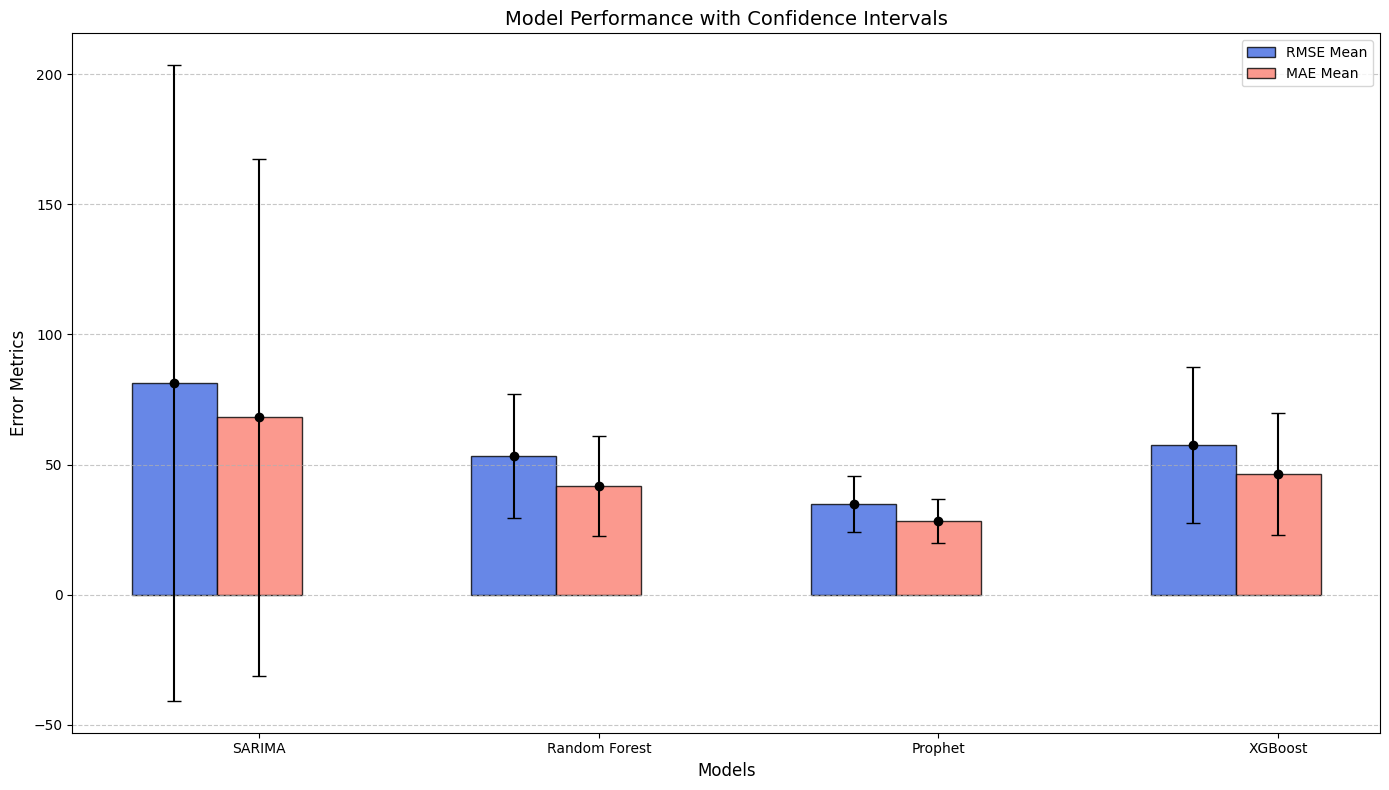

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Plot RMSE, MAE, and MAPE with Confidence Intervals
plt.figure(figsize=(14, 8))

x = np.arange(len(cv_results_df["Model"]))  # Bar positions
width = 0.25  # Reduced width to fit all three bars comfortably

# RMSE Plot
plt.bar(x - width, cv_results_df["RMSE Mean"], width, label="RMSE Mean", color="royalblue", alpha=0.8, edgecolor="black")
plt.errorbar(x - width, cv_results_df["RMSE Mean"],
             yerr=[cv_results_df["RMSE Mean"] - cv_results_df["RMSE CI Lower"],
                   cv_results_df["RMSE CI Upper"] - cv_results_df["RMSE Mean"]],
             fmt='o', color='black', capsize=5)

# MAE Plot
plt.bar(x, cv_results_df["MAE Mean"], width, label="MAE Mean", color="salmon", alpha=0.8, edgecolor="black")
plt.errorbar(x, cv_results_df["MAE Mean"],
             yerr=[cv_results_df["MAE Mean"] - cv_results_df["MAE CI Lower"],
                   cv_results_df["MAE CI Upper"] - cv_results_df["MAE Mean"]],
             fmt='o', color='black', capsize=5)


# Labels and Titles
plt.xticks(x, cv_results_df["Model"], fontsize=10)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Error Metrics", fontsize=12)
plt.title("Model Performance with Confidence Intervals", fontsize=14)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


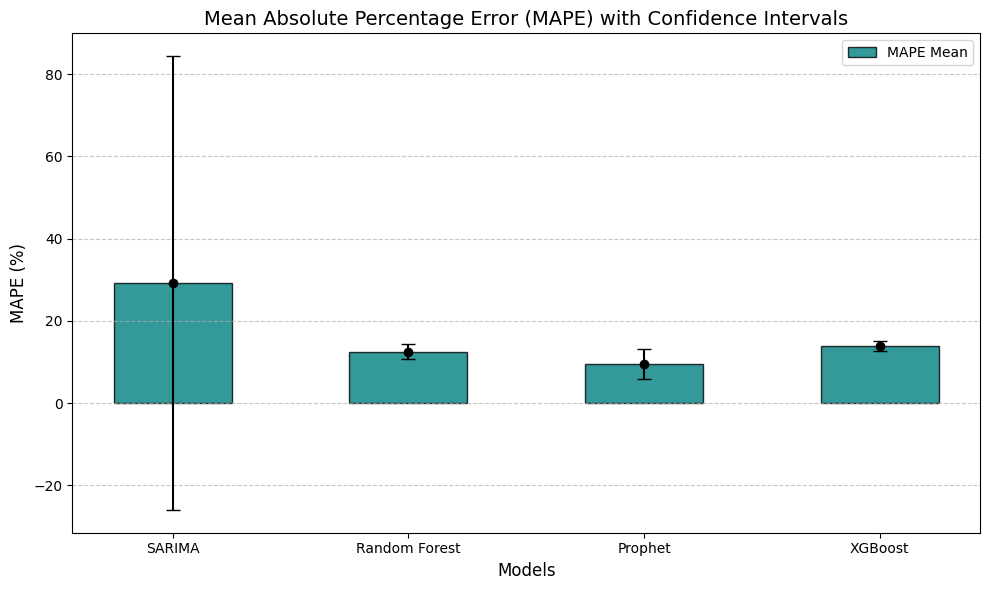

In [33]:
# Plot MAPE with Confidence Intervals
plt.figure(figsize=(10, 6))

x = np.arange(len(cv_results_df["Model"]))  # Bar positions

# MAPE Plot
plt.bar(x, cv_results_df["MAPE Mean"], width=0.5, color="teal", alpha=0.8, edgecolor="black", label="MAPE Mean")
plt.errorbar(x, cv_results_df["MAPE Mean"],
             yerr=[cv_results_df["MAPE Mean"] - cv_results_df["MAPE CI Lower"],
                   cv_results_df["MAPE CI Upper"] - cv_results_df["MAPE Mean"]],
             fmt='o', color='black', capsize=5)

# Labels and Titles
plt.xticks(x, cv_results_df["Model"], fontsize=10)
plt.xlabel("Models", fontsize=12)
plt.ylabel("MAPE (%)", fontsize=12)
plt.title("Mean Absolute Percentage Error (MAPE) with Confidence Intervals", fontsize=14)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()
